Bohua Liu is responsible for this code

## Class distribution (balance) 

Load YOLO dataset info

In [2]:
import os, json, yaml, glob
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

with open("yolo_4cats/taco.yaml", "r") as f:
    data = yaml.safe_load(f)

names = data.get("names", [])

if isinstance(names, dict):
    names = [names[k] for k in sorted(names.keys())]
    
print(f"Number of classes: {len(names)}")
print("First few class names:", names[:10])

Number of classes: 4
First few class names: ['plastic', 'glass', 'paper', 'unsorted']


**Find all image paths & Count labels per class**

In [3]:
def collect_images(path):
    if os.path.isdir(path):
        images = []
        for ext in [".jpg"]:
            images += glob.glob(os.path.join(path, f"**/*{ext}"), recursive=True)
        return images
    elif os.path.isfile(path):
        with open(path) as f:
            return [ln.strip() for ln in f if ln.strip()]
    else:
        return []

train_images = collect_images(os.path.join(os.getcwd()+"/yolo_4cats", data["train"]))
val_images = collect_images(os.path.join(os.getcwd()+"/yolo_4cats", data["val"]))
print(f"Train images: {len(train_images)}, Val images: {len(val_images)}")


def get_label_path(img_path):
    # Replace "images" with "labels" and .jpg → .txt
    label_path = img_path.replace("images", "labels")
    label_path = os.path.splitext(label_path)[0] + ".txt"
    return label_path

counts = Counter()
for img in train_images:
    label_path = get_label_path(img)
    if not os.path.exists(label_path):
        continue
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 1:
                try:
                    cls = int(float(parts[0]))
                    counts[cls] += 1
                except:
                    pass



Train images: 1275, Val images: 225


**Plot**

,class_id,class_name,instances
0,0,plastic,1942
3,3,unsorted,1483
2,2,paper,426
1,1,glass,228


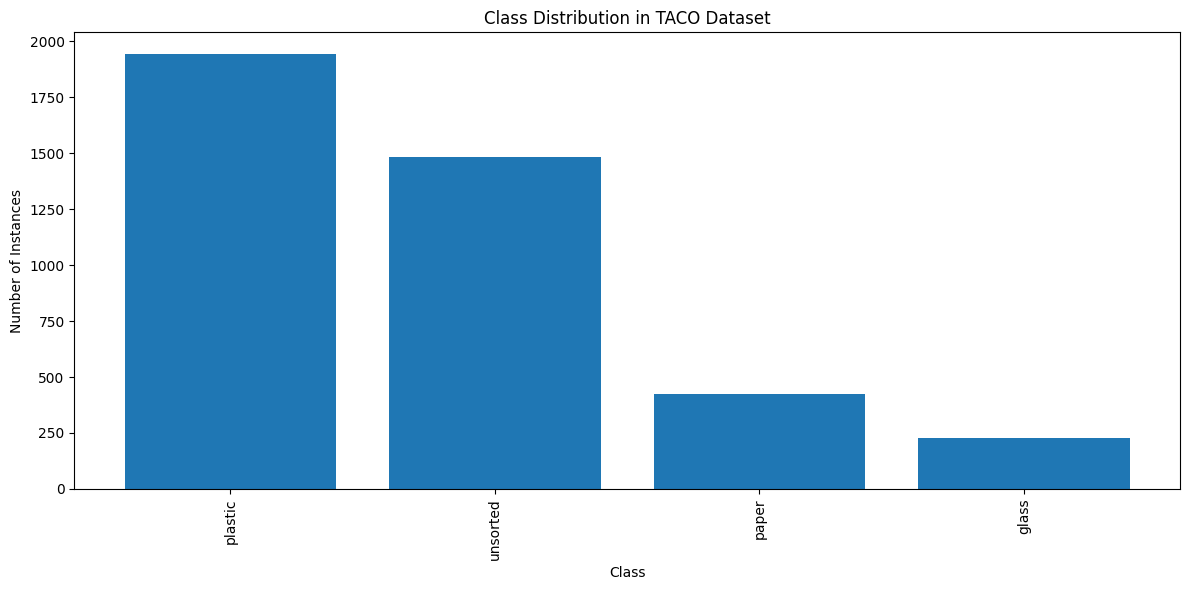

In [3]:
rows = [{"class_id": i, "class_name": names[i], "instances": counts[i]} for i in range(len(names))]
df = pd.DataFrame(rows).sort_values("instances", ascending=False)

display(df.head(28))
# df.to_csv("class_distribution.csv", index=False)

plt.figure(figsize=(12,6))
plt.bar(df["class_name"], df["instances"])
plt.xticks(rotation=90)
plt.title("Class Distribution in TACO Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Instances")
plt.tight_layout()
plt.show()


## Object size distribution

What to look for
* % of small (<1%), medium (1–5%), large (>5%) boxes.

In [ ]:
# Params (tweak if you like)
SMALL_THR  = 0.01   # area_ratio < 0.01  => small
MEDIUM_THR = 0.05   # area_ratio < 0.05 => medium, else large

# Collect boxes 
def _boxes_from_data(data_imgs):
    for img_path in data_imgs:
        lp = get_label_path(img_path)
        if not os.path.exists(lp):
            continue
        with open(lp) as f:
            for ln in f:
                p = ln.strip().split()
                if len(p) < 5:
                    continue
                try:
                    cls = int(float(p[0]))
                    x, y, w, h = map(float, p[1:5])
                except Exception:
                    continue
                area = w * h
                bucket = "small" if area < SMALL_THR else ("medium" if area < MEDIUM_THR else "large")
                yield {
                    "image": img_path,
                    "cls": cls,
                    "class_name": names[cls] if 0 <= cls < len(names) else str(cls),
                    "x": x, "y": y, "w": w, "h": h,
                    "area_ratio": area,
                    "size_bucket": bucket,
                }

import pandas as pd
import matplotlib.pyplot as plt

all_images = train_images + val_images
data_rows = list(_boxes_from_data(all_images))
df_data_sizes = pd.DataFrame(data_rows)

print(f"All images: {len(all_images)}")
print(f"Total all boxes: {len(df_data_sizes)}")
display(df_data_sizes.head(10))


All images: 1500
Total all boxes: 4784


,image,cls,class_name,x,y,w,h,area_ratio,size_bucket
0,/Users/yw/Desktop/final project files/yolo_4ca...,0,plastic,0.479779,0.398284,0.153186,0.093750,0.014361,medium
1,/Users/yw/Desktop/final project files/yolo_4ca...,0,plastic,0.549939,0.812296,0.026961,0.034722,0.000936,small
2,/Users/yw/Desktop/final project files/yolo_4ca...,0,plastic,0.097580,0.828636,0.015625,0.013480,0.000211,small
3,/Users/yw/Desktop/final project files/yolo_4ca...,0,plastic,0.390012,0.463644,0.067402,0.127451,0.008590,small
4,/Users/yw/Desktop/final project files/yolo_4ca...,3,unsorted,0.620864,0.605188,0.024816,0.028186,0.000699,small
5,/Users/yw/Desktop/final project files/yolo_4ca...,3,unsorted,0.509498,0.445670,0.011642,0.032680,0.000380,small
6,/Users/yw/Desktop/final project files/yolo_4ca...,0,plastic,0.531556,0.181985,0.031250,0.037173,0.001162,small
7,/Users/yw/Desktop/final project files/yolo_4ca...,3,unsorted,0.493859,0.633072,0.309020,0.208581,0.064456,large
8,/Users/yw/Desktop/final project files/yolo_4ca...,0,plastic,0.216708,0.276961,0.140931,0.036765,0.005181,small
9,/Users/yw/Desktop/final project files/yolo_4ca...,3,unsorted,0.302875,0.462445,0.029750,0.046601,0.001386,small


In [ ]:
bucket_counts = (
    df_data_sizes["size_bucket"]
    .value_counts()
    .reindex(["small", "medium", "large"])
    .fillna(0)
    .astype(int)
)
bucket_pct = (bucket_counts / bucket_counts.sum() * 100).round(2)
summary_train = pd.DataFrame({"count": bucket_counts, "percent": bucket_pct})
display(summary_train)

# Quick percentiles of area_ratio (helps pick img size / model scale)
q = df_data_sizes["area_ratio"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(5)
print("area_ratio percentiles (10/25/50/75/90%):")
display(q)


,count,percent
size_bucket,,
small,3215,67.20
medium,968,20.23
large,601,12.56


area_ratio percentiles (10/25/50/75/90%):


0.10    0.00015
0.25    0.00050
0.50    0.00350
0.75    0.01762
0.90    0.06846
Name: area_ratio, dtype: float64

## Image resolution & aspect ratio

What to look for
* Wide spread of image sizes (e.g., some 300×400, others 4000×3000).
* Very different aspect ratios (e.g., 1:1 vs 16:9 vs 9:16).

In [4]:
from PIL import Image
import numpy as np

# Collect all images (train + val + test) using your existing lists
all_images = train_images + val_images
print(f"Total images to analyze: {len(all_images)}")

image_data = []

for img_path in all_images:
    try:
        with Image.open(img_path) as im:
            w, h = im.size
    except Exception as e:
        # skip unreadable image
        print(f"Skipping {img_path}: {e}")
        continue

    aspect_ratio = w / h if h > 0 else np.nan
    orientation = (
        "square-ish" if 0.95 <= aspect_ratio <= 1.05 
        else "landscape" if aspect_ratio > 1.05 
        else "portrait"
    )

    image_data.append({
        "image": img_path,
        "width": w,
        "height": h,
        "aspect_ratio": aspect_ratio,
        "orientation": orientation,
        "megapixels": (w * h) / 1e6
    })

df_aspect = pd.DataFrame(image_data)
display(df_aspect.head())

# Summary statistics
print("\n Basic stats:")
# Select only numeric columns manually for compatibility
num_cols = df_aspect.select_dtypes(include=["number"])
display(num_cols.describe())

print("\n Orientation breakdown:")
display(df_aspect["orientation"].value_counts())

# Top resolutions
df_aspect["resolution"] = df_aspect["width"].astype(str) + "x" + df_aspect["height"].astype(str)
top_res = df_aspect["resolution"].value_counts().head(15)
print("\n Top 15 resolutions:")
display(top_res)

Total images to analyze: 1500


,image,width,height,aspect_ratio,orientation,megapixels
0,/Users/yw/Desktop/final project files/yolo_4ca...,2448,3264,0.750000,portrait,7.990272
1,/Users/yw/Desktop/final project files/yolo_4ca...,3264,2448,1.333333,landscape,7.990272
2,/Users/yw/Desktop/final project files/yolo_4ca...,3264,2448,1.333333,landscape,7.990272
3,/Users/yw/Desktop/final project files/yolo_4ca...,3024,4032,0.750000,portrait,12.192768
4,/Users/yw/Desktop/final project files/yolo_4ca...,2448,3264,0.750000,portrait,7.990272



 Basic stats:


,width,height,aspect_ratio,megapixels
count,1500.000000,1500.000000,1500.000000,1500.000000
mean,2967.672000,3080.037333,1.020880,9.091855
std,909.670141,681.720408,0.406455,3.287910
min,842.000000,474.000000,0.456000,0.399108
25%,2448.000000,2448.000000,0.750000,7.990272
50%,2921.500000,3264.000000,0.750000,7.990272
75%,3264.000000,3264.000000,1.333333,12.192768
max,6000.000000,4618.000000,2.192982,24.000000



 Orientation breakdown:


orientation
portrait      861
landscape     634
square-ish      5
Name: count, dtype: int64


 Top 15 resolutions:


resolution
2448x3264    490
3264x2448    280
1824x4000    105
4032x3024    101
3120x4160     84
4160x3120     69
3024x4032     61
4000x1824     46
5312x2988     44
1537x2049     35
1536x2048     27
2268x4032     24
6000x4000     20
2624x1968     14
2049x1537     12
Name: count, dtype: int64

## Per-image instance count


Summary statistics for training set:


count    1275.000000
mean        3.199216
std         4.865168
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        90.000000
Name: inst_count, dtype: float64


Empty images (0 objects): 0
Single-object images:      520
Dense images (>30 objects): 6


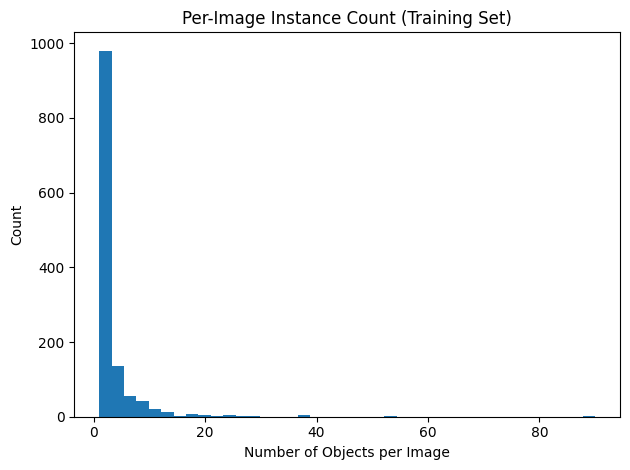

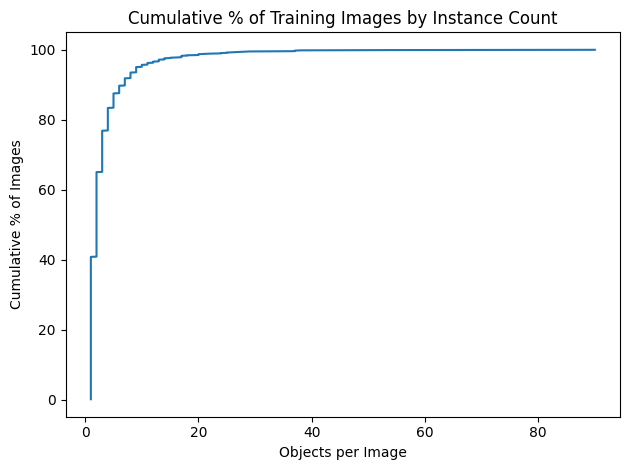


Top 20 densest training images:


,image,inst_count
977,/Users/yw/Desktop/project/dataset_yolo_4cats/i...,90
711,/Users/yw/Desktop/project/dataset_yolo_4cats/i...,54
843,/Users/yw/Desktop/project/dataset_yolo_4cats/i...,38
1025,/Users/yw/Desktop/project/dataset_yolo_4cats/i...,37
124,/Users/yw/Desktop/project/dataset_yolo_4cats/i...,37
142,/Users/yw/Desktop/project/dataset_yolo_4cats/i...,37
484,/Users/yw/Desktop/project/dataset_yolo_4cats/i...,29
249,/Users/yw/Desktop/project/dataset_yolo_4cats/i...,28
111,/Users/yw/Desktop/project/dataset_yolo_4cats/i...,27
565,/Users/yw/Desktop/project/dataset_yolo_4cats/i...,26


In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- config ---
DENSE_THRESH = 30  # images with > this many objects are "dense"
OUT_DIR = "train_instance_analysis"

rows = []
missing_label_files = 0

for img in train_images:
    lbl = get_label_path(img)
    inst = 0
    bad_lines = 0
    if os.path.exists(lbl):
        with open(lbl) as f:
            for ln in f:
                ln = ln.strip()
                if not ln:
                    continue
                parts = ln.split()
                # YOLO line: cls cx cy w h
                if len(parts) < 5:
                    bad_lines += 1
                    continue
                inst += 1
    else:
        missing_label_files += 1

    rows.append({
        "image": img,
        "label_path": lbl,
        "inst_count": inst,
        "bad_label_lines": bad_lines,
        "has_label_file": os.path.exists(lbl)
    })

df_train_inst = pd.DataFrame(rows)

# ---- summary ----
print("\nSummary statistics for training set:")
summary = df_train_inst["inst_count"].describe()
display(summary)

empty = (df_train_inst["inst_count"] == 0).sum()
one_obj = (df_train_inst["inst_count"] == 1).sum()
dense = (df_train_inst["inst_count"] > DENSE_THRESH).sum()

print(f"\nEmpty images (0 objects): {empty}")
print(f"Single-object images:      {one_obj}")
print(f"Dense images (>{DENSE_THRESH} objects): {dense}")

# ---- plots ----
plt.figure()
plt.hist(df_train_inst["inst_count"], bins=40)
plt.title("Per-Image Instance Count (Training Set)")
plt.xlabel("Number of Objects per Image")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Cumulative distribution
counts_sorted = df_train_inst["inst_count"].sort_values().values
cum = (pd.Series(counts_sorted).rank(method="first").values / len(counts_sorted)) * 100
plt.figure()
plt.plot(counts_sorted, cum)
plt.title("Cumulative % of Training Images by Instance Count")
plt.xlabel("Objects per Image")
plt.ylabel("Cumulative % of Images")
plt.tight_layout()
plt.show()

# Top-N densest images
print("\nTop 20 densest training images:")
display(df_train_inst.sort_values("inst_count", ascending=False).head(20)[["image", "inst_count"]])
